# Introducción a las Matemáticas de la Ciencia de Datos

Este cuaderno de Google Colab introduce el uso de la ciencia de datos para explorar cómo las matemáticas y las herramientas analíticas nos ayudan a entender y resolver problemas del mundo real. Utilizaremos un conjunto de datos (MuertesMaternas.csv) para entender cómo se comportan las variables y, lo más importante, cómo los números pueden revelarnos u ocultarnos la realidad de las minorías vulnerables.

**Conceptos que veremos:**

*   Medidas de Tendencia Central (Media, Mediana, Moda).
*   Medidas de Dispersión.
*   Distribución de Datos y Sesgos.

# Preparación del Entorno y Carga de Datos

Antes de iniciar el análisis, el primer paso es preparar el entorno de trabajo cargando las librerías necesarias (pandas, matplotlib y sns) y conectando Google Drive para abrir el archivo MuertesMaternas.csv.

En este punto realizamos una limpieza de datos esencial: filtramos el conjunto de datos para conservar únicamente las edades reales (menores a 100 años). En bases de datos reales es común usar códigos como 998 para indicar que un dato no se conoce; si dejáramos esos valores falsos, alterarían por completo los cálculos matemáticos y promedios posteriores.

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')
sns.set_theme(style="whitegrid")

ruta_archivo = '/content/drive/MyDrive/Colab Notebooks/MuertesMaternas.csv'

try:
    df = pd.read_csv(ruta_archivo, encoding='latin-1')
except UnicodeDecodeError:
    df = pd.read_csv(ruta_archivo, encoding='utf-8')

casos_atipicos = df[df['EDAD'] >= 100].shape[0]
print(f"Se detectaron {casos_atipicos} registros con edades no especificadas (como el código 998).")

df_limpio = df[df['EDAD'] < 100]
print(f"Registros restantes para el análisis: {df_limpio.shape[0]}\n")
df_limpio.head()

Mounted at /content/drive
Se detectaron 25 registros con edades no especificadas (como el código 998).
Registros restantes para el análisis: 19907



,ANIO_NACIMIENTO,MES_NACIMIENTO,MES_NACIMIENTOD,DIA_NACIMIENTO,EDAD,ESTADO_CONYUGAL,ESTADO_CONYUGALD,ENTIDAD_RESIDENCIA,ENTIDAD_RESIDENCIAD,MUNICIPIO_RESIDENCIA,...,DIA_REGISTRO,ANIO_CERTIFICACION,MES_CERTIFICACION,MES_CERTIFICACIOND,DIA_CERTIFICACION,ANIO_BASE_DATOS,RAZON_MORTALIDAD_MATERNA,RAZON_MORTALIDAD_MATERNAD,EDAD_QUINQUENAL,EDAD_QUINQUENALD
0,0,0,NO ESPECIFICADO,0,35,4,UNION LIBRE,8,CHIHUAHUA,29,...,5,0,0,NO ESPECIFICADO,0,2002,1,MUERTES MATERNAS PARA LA RAZÓN DE MORTALIDAD M...,6,35 a 39 años
1,0,0,NO ESPECIFICADO,0,20,5,CASADO,8,CHIHUAHUA,47,...,6,0,0,NO ESPECIFICADO,0,2002,1,MUERTES MATERNAS PARA LA RAZÓN DE MORTALIDAD M...,3,20 a 24 años
2,1962,7,JULIO,12,39,5,CASADO,12,GUERRERO,20,...,24,0,0,NO ESPECIFICADO,0,2002,1,MUERTES MATERNAS PARA LA RAZÓN DE MORTALIDAD M...,6,35 a 39 años
3,1974,2,FEBRERO,10,27,5,CASADO,12,GUERRERO,41,...,17,0,0,NO ESPECIFICADO,0,2002,1,MUERTES MATERNAS PARA LA RAZÓN DE MORTALIDAD M...,4,25 a 29 años
4,1980,4,ABRIL,18,20,4,UNION LIBRE,18,NAYARIT,9,...,15,0,0,NO ESPECIFICADO,0,2002,1,MUERTES MATERNAS PARA LA RAZÓN DE MORTALIDAD M...,3,20 a 24 años


# 1.- La Media (El Promedio)

La Media (o promedio) es la suma de todos los valores dividida entre el número total de casos. Aunque es la medida estadística más común y utilizada, tiene un punto débil importante: es muy sensible a los valores extremos (atípicos).

Por ejemplo, si la mayoría de las muertes maternas ocurren en edades jóvenes, pero registramos unos cuantos casos de edades muy avanzadas, el promedio se elevará significativamente. Esto puede darnos una falsa impresión de la situación real si nos quedamos únicamente con este número.

In [ ]:
# Calculamos la Media de la columna 'EDAD'
media_nacional = df_limpio['EDAD'].mean()

print(f"La edad promedio (Media) de muerte materna a nivel nacional es: {media_nacional:.2f} años")

La edad promedio (Media) de muerte materna a nivel nacional es: 28.48 años


# 2. Mediana y Moda

Para evitar que los valores extremos distorsionen nuestro análisis, recurrimos a otras dos medidas estadísticas fundamentales:

*   La Mediana: Si ordenáramos a todas las mujeres de menor a mayor edad, la mediana es el valor que se encuentra exactamente en medio de la fila. Esto significa que el 50% de los casos ocurrieron en edades menores o iguales a este número, y el otro 50% en edades mayores. A diferencia de la media, la mediana no se altera por los valores extremos.

*   La Moda: Es simplemente el valor numérico que más veces se repite en todo el conjunto de datos; es decir, la edad más frecuente en la que ocurren las muertes maternas.


In [ ]:
# Calculamos Mediana y Moda de la columna 'EDAD'
mediana_nacional = df_limpio['EDAD'].median()
moda_nacional = df_limpio['EDAD'].mode()[0]  # mode() puede devolver varios valores, tomamos el primero

print(f"La Mediana de edad a nivel nacional es: {mediana_nacional:.2f} años")
print(f"La Moda (edad más frecuente) es: {moda_nacional:.2f} años")

La Mediana de edad a nivel nacional es: 28.00 años
La Moda (edad más frecuente) es: 30.00 años


# 3. El Peligro de los Promedios: El Caso de Chiapas

La estadística nos plantea una pregunta vital: Si la Media y la Mediana a nivel nacional o estatal son prácticamente iguales (alrededor de los 28 años), ¿por qué deberíamos preocuparnos por analizar la moda o ver la forma completa de la gráfica?

Insight de política pública: Porque los promedios esconden a las minorías vulnerables. Un promedio general estable puede ocultar por completo una crisis de mortalidad en adolescentes si no observamos los "picos" o subgrupos dentro de la distribución de los datos.

Imagina que eres un tomador de decisiones en el gobierno federal y te entregan un reporte que solo incluye la mediana de edad, indicando que es de 28 años. Si te basas únicamente en ese dato, diseñarás programas de salud reproductiva dirigidos exclusivamente a mujeres adultas (de 20 a 30 años), cometiendo el grave error de ignorar la necesidad urgente de prevención y atención al embarazo adolescente en sectores específicos.

Vamos a aislar los datos de Chiapas para comprobar el comportamiento de sus métricas básicas.

In [ ]:
# Filtramos los datos para la entidad de residencia: CHIAPAS
df_chiapas = df_limpio[df_limpio['ENTIDAD_RESIDENCIAD'] == 'CHIAPAS']

# Calculamos sus medidas de tendencia central
media_chiapas = df_chiapas['EDAD'].mean()
mediana_chiapas = df_chiapas['EDAD'].median()
moda_chiapas = df_chiapas['EDAD'].mode()[0]

# Desplegamos los resultados
print(f"Métricas en Chiapas:")
print(f" - Media:   {media_chiapas:.2f} años")
print(f" - Mediana: {mediana_chiapas:.2f} años")
print(f" - Moda:    {moda_chiapas:.2f} años")

Métricas en Chiapas:
 - Media:   28.26 años
 - Mediana: 28.00 años
 - Moda:    20.00 años


# 4. Distribución de los Datos y Sesgos (Skewness)

Para entender verdaderamente un fenómeno, los científicos de datos no solo miran números aislados; visualizan la "forma" en que se distribuyen los datos mediante herramientas como los histogramas. La relación entre las medidas que calculamos antes define la simetría de la gráfica:


*   Distribución Normal (Simétrica): La Media, Mediana y Moda coinciden exactamente en el centro, creando una forma de campana perfecta.

*   Sesgo a la Derecha (Positivo): La Media es mayor que la Mediana. Unos cuantos casos con valores o edades muy altas "jalan" el promedio hacia el extremo derecho.

*   Sesgo a la Izquierda (Negativo): La Media es menor que la Mediana. Existe una concentración de casos en valores o edades muy tempranas que "jalan" el promedio hacia abajo.

Vamos a generar la gráfica del estado de Chiapas para descubrir visualmente esos "picos ocultos" que las métricas resumidas no nos revelaron.




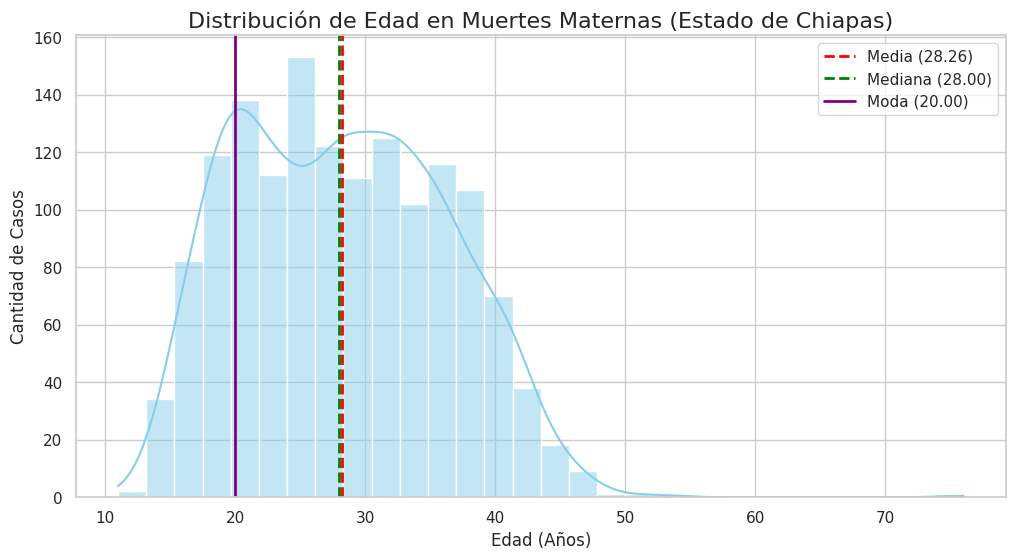

In [ ]:
# Crear el contenedor de la gráfica con un tamaño adecuado
plt.figure(figsize=(12, 6))

# Dibujar el histograma de edades con una línea de tendencia (KDE)
sns.histplot(df_chiapas['EDAD'], bins=30, kde=True, color='skyblue')

# Dibujar líneas verticales para identificar visualmente la Media, Mediana y Moda
plt.axvline(media_chiapas, color='red', linestyle='dashed', linewidth=2, label=f'Media ({media_chiapas:.2f})')
plt.axvline(mediana_chiapas, color='green', linestyle='dashed', linewidth=2, label=f'Mediana ({mediana_chiapas:.2f})')
plt.axvline(moda_chiapas, color='purple', linestyle='solid', linewidth=2, label=f'Moda ({moda_chiapas:.2f})')

# Personalizar títulos y etiquetas de los ejes
plt.title('Distribución de Edad en Muertes Maternas (Estado de Chiapas)', fontsize=16)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Cantidad de Casos', fontsize=12)

# Mostrar la leyenda de colores para cada métrica y desplegar el gráfico
plt.legend()
plt.show()

Análisis Crítico: Al ejecutar la gráfica, observa con atención la parte izquierda (edades jóvenes). Aunque la media y la mediana marcan los 28 años, notarás cómo se levanta un pico muy marcado de casos en mujeres menores de 20 años (adolescentes). Las métricas globales escondían este problema, pero la gráfica lo hace evidente.

# 5. Medidas de Dispersión

Saber dónde está el centro de los datos (el promedio) no es suficiente; necesitamos comprender qué tan "dispersos", distribuidos o alejados están los valores individuales respecto a ese promedio. Para medir esta variabilidad, utilizamos:

*   El Rango: Es la distancia total entre el valor más pequeño y el más grande del conjunto de datos. Nos da una idea de los límites de nuestra información.

*   La Varianza: Mide la distancia promedio de cada dato respecto a la media. Como se calcula elevando esas diferencias al cuadrado (para evitar que los números negativos se cancelen), su resultado queda en unidades al cuadrado (por ejemplo, años cuadrados), lo cual es difícil de interpretar en la vida real.

*   La Desviación Estándar: Es simplemente la raíz cuadrada de la varianza. Al aplicar la raíz, devolvemos el resultado a la unidad de medida original (años). Nos indica, en promedio, cuántos años se desvían o alejan las edades reales de las mujeres respecto a la Media general.




In [ ]:
# Calculamos las medidas de dispersión para los datos nacionales
rango_min = df_limpio['EDAD'].min()
rango_max = df_limpio['EDAD'].max()
varianza = df_limpio['EDAD'].var()
desviacion_std = df_limpio['EDAD'].std()

# Desplegamos los resultados
print(f"Rango de edades: de {rango_min} a {rango_max} años.")
print(f"Varianza (en años al cuadrado): {varianza:.2f}")
print(f"Desviación Estándar: {desviacion_std:.2f} años")

# Interpretación práctica para los estudiantes
print(f"\nInterpretación analítica: En México, aunque la edad promedio (Media) es de aproximadamente {media_nacional:.1f} años, ")
print(f"la desviación estándar nos advierte que la mayoría de los casos fluctúan (hacia arriba o hacia abajo) ")
print(f"en un margen de ±{desviacion_std:.1f} años respecto a ese promedio.")

Rango de edades: de 11 a 86 años.
Varianza (en años al cuadrado): 56.12
Desviación Estándar: 7.49 años

Interpretación analítica: En México, aunque la edad promedio (Media) es de aproximadamente 28.5 años, 
la desviación estándar nos advierte que la mayoría de los casos fluctúan (hacia arriba o hacia abajo) 
en un margen de ±7.5 años respecto a ese promedio.


# 6. Estudio Comparativo: Chiapas vs. Michoacán (Dos realidades bajo la misma Mediana)

Aceptar un promedio o una mediana sin cuestionarla es uno de los errores más comunes en el análisis de datos públicos. La presentación nos plantea un escenario crítico: imagina que trabajas en el gobierno federal y te entregan un reporte que indica que tanto Chiapas como Michoacán tienen exactamente la misma Mediana de edad (28 años).

Si te limitas a ese dato resumido, asumirías que ambos estados enfrentan la misma situación y diseñarías la misma estrategia de salud para los dos. Vamos a cruzar las métricas de ambos estados para descubrir si realmente esconden la misma realidad.



In [ ]:
# Filtrar de forma segura usando texto parcial para evitar errores de nombres largos o acentos
df_chiapas = df_limpio[df_limpio['ENTIDAD_RESIDENCIAD'].str.contains('CHIAPAS', na=False)]
df_michoacan = df_limpio[df_limpio['ENTIDAD_RESIDENCIAD'].str.contains('MICHOA', na=False)]

# Calcular Mediana y Moda para Chiapas
mediana_ch = df_chiapas['EDAD'].median()
moda_ch = df_chiapas['EDAD'].mode()[0]

# Calcular Mediana y Moda para Michoacán
mediana_mich = df_michoacan['EDAD'].median()
moda_mich = df_michoacan['EDAD'].mode()[0]

# Imprimir la comparativa en pantalla
print("COMPARATIVA DE MÉTRICAS REGIONALES:")
print(f"Chiapas   -> Mediana: {mediana_ch:.0f} años | Moda (Edad más frecuente): {moda_ch:.0f} años")
print(f"Michoacán -> Mediana: {mediana_mich:.0f} años | Moda (Edad más frecuente): {moda_mich:.0f} años")

COMPARATIVA DE MÉTRICAS REGIONALES:
Chiapas   -> Mediana: 28 años | Moda (Edad más frecuente): 20 años
Michoacán -> Mediana: 29 años | Moda (Edad más frecuente): 25 años


# 7. Visualizando la Disparidad: Curvas de Densidad (KDE)

El cálculo anterior nos revela algo impactante: aunque ambos estados comparten la misma Mediana (28-29 años), sus Modas son completamente diferentes. En Chiapas la edad más frecuente es significativamente menor que en Michoacán.

Para entender esto a fondo, utilizaremos un gráfico llamado Curva de Densidad (KDE). A diferencia del histograma de barras, esta gráfica suaviza los datos y nos permite comparar dos distribuciones directamente en el mismo espacio, mostrando con precisión dónde se concentra el volumen de los casos.

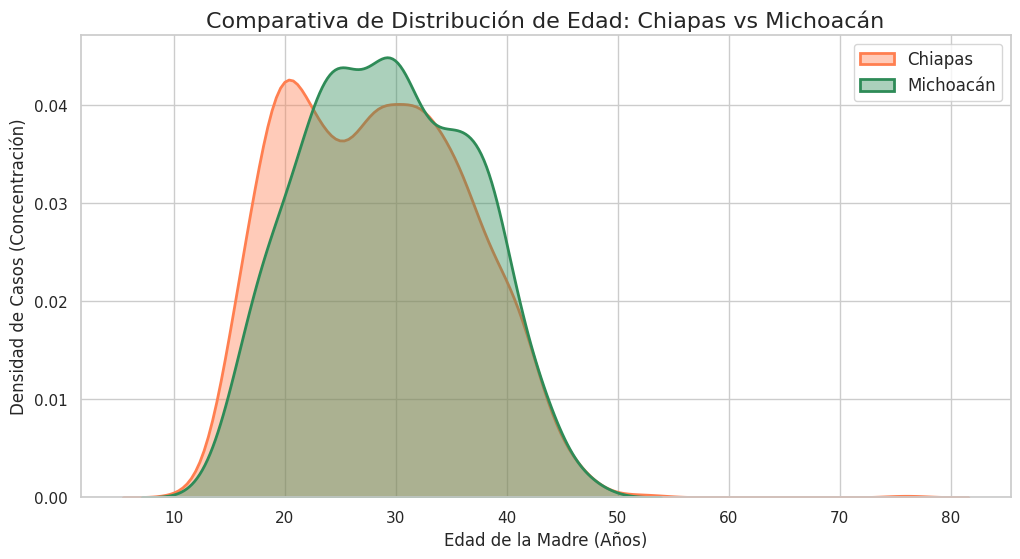

In [ ]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Dibujar las curvas de densidad para ambos estados
sns.kdeplot(df_chiapas['EDAD'], label='Chiapas', fill=True, color='coral', alpha=0.4, linewidth=2)
sns.kdeplot(df_michoacan['EDAD'], label='Michoacán', fill=True, color='seagreen', alpha=0.4, linewidth=2)

# Personalizar el gráfico
plt.title('Comparativa de Distribución de Edad: Chiapas vs Michoacán', fontsize=16)
plt.xlabel('Edad de la Madre (Años)', fontsize=12)
plt.ylabel('Densidad de Casos (Concentración)', fontsize=12)

# Mostrar etiquetas y desplegar
plt.legend(fontsize=12)
plt.show()

# 8. Conclusión Crítica e Impacto en la Política Pública

Al ejecutar el gráfico anterior, la diferencia matemática se traduce en un diagnóstico social completamente claro para un científico de datos:

*   El caso de Chiapas: Muestra una curva con una "joroba" o pico muy pronunciado en la juventud. Estamos ante una crisis concentrada en mortalidad materna adolescente.


*   El caso de Michoacán: Su curva está más centrada y distribuida hacia edades maduras. Esto representa un perfil de crisis obstétrica en mujeres adultas.



**Aprendizaje clave de la práctica:**
Si nos hubiéramos quedado únicamente con la Mediana general de 28 años, habríamos diseñado programas de atención estándar para mujeres adultas en ambos estados. Al hacer esto, habríamos dejado en el total desamparo y olvido a las adolescentes de Chiapas.

Los números tienen el poder de revelar realidades complejas, pero los resúmenes estadísticos simplistas tienen el peligro de ocultar a las minorías más vulnerables. El verdadero trabajo del analista es saber cuándo profundizar para tomar decisiones informadas y éticas.